# Malaria model ranking

Multi-criteria ranking of malaria scam fits. Loads per-task summary CSVs
from a `scam_fits` run, lets you pick which metrics to rank on, runs
Kendall τ on the chosen metrics, then Borda / TOPSIS / Pareto / pairwise
dominance, and surfaces a winners-by-method comparison.

Mirrors `dh_final_diagnostics.ipynb` from idd-tc-mortality.

In [102]:
%load_ext autoreload
%autoreload 2

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from idd_forecast_mbp.select.model_selection import (
    CONFIG_COLS,
    DEFAULT_METRICS,
    NO_FE_METRICS,
    CALIBRATION_METRICS,
    kendall_tau_heatmap,
    borda_rank,
    topsis_rank,
    pareto_frontier,
    pairwise_dominance_summary,
)

%matplotlib inline
plt.rcParams['figure.dpi'] = 100
pd.options.display.max_columns = 80
pd.options.display.width = 160

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Paths

Edit `FIT_OUTPUT_DIR` to point at the scam_fits run you want to rank.
Each task writes one `*summary*.csv` in this dir; the load cell
concatenates them.

In [2]:
FIT_OUTPUT_DIR = Path(
    '/mnt/team/idd/pub/forecast-mbp/03-modeling_data/malaria/scam_fits/lsae_1285/20260512_v2'
)

assert FIT_OUTPUT_DIR.exists(), f'Missing: {FIT_OUTPUT_DIR}'
summary_files = sorted(FIT_OUTPUT_DIR.glob('*summary*.csv'))
print(f'Found {len(summary_files)} summary CSVs in {FIT_OUTPUT_DIR}')

Found 210 summary CSVs in /mnt/team/idd/pub/forecast-mbp/03-modeling_data/malaria/scam_fits/lsae_1285/20260512_v2


## Load

One row per task. Columns described in `model_selection.py` module docstring.

In [8]:
CALIBRATION_METRICS

[]

In [9]:
df = pd.concat(
    [pd.read_csv(p) for p in summary_files],
    ignore_index=True,
)

metric_df = df[CONFIG_COLS + list(DEFAULT_METRICS.keys()) + list(NO_FE_METRICS.keys())]

print(f'metric_df: {metric_df.shape[0]:,} rows × {metric_df.shape[1]} cols')
print(f'task_id range: {metric_df["task_id"].min()} .. {metric_df["task_id"].max()}')
print(f'duplicate task_ids: {metric_df["task_id"].duplicated().sum()}')
metric_df.head()

metric_df: 210 rows × 23 cols
task_id range: 1 .. 210
duplicate task_ids: 0


,task_id,is_aic,is_bic,is_deviance,is_dev_expl,is_r_sq,is_rmse,is_mae,oos_rmse,oos_mae,oos_r_sq,is_pfpr_rmse,is_pfpr_mae,is_pfpr_r,oos_pfpr_rmse,oos_pfpr_mae,oos_pfpr_r,is_no_fe_aic,is_no_fe_bic,is_no_fe_dev_expl,is_no_fe_r_sq,is_no_fe_rmse,is_no_fe_mae
0,1,1.412473e+06,1.413252e+06,2.322035e+06,0.818854,0.818854,2.847173,1.985712,5.615491,4.590519,0.295347,0.080750,0.034013,0.875502,0.178830,0.082469,0.255125,1.735822e+06,1.735864e+06,0.439616,0.439616,5.007753,4.052990
1,2,1.412234e+06,1.413019e+06,2.320093e+06,0.819006,0.819006,2.845982,1.984020,5.399969,4.451391,0.348398,0.080420,0.033871,0.877103,0.179908,0.084052,0.161549,1.717726e+06,1.717790e+06,0.473932,0.473932,4.852004,3.947641
2,3,1.412221e+06,1.412995e+06,2.320001e+06,0.819013,0.819013,2.845925,1.983988,5.615517,4.590538,0.295340,0.080431,0.033877,0.877081,0.178830,0.082469,0.255106,1.735822e+06,1.735865e+06,0.439616,0.439616,5.007753,4.052990
3,4,1.412389e+06,1.413179e+06,2.321342e+06,0.818909,0.818909,2.846747,1.985197,5.375138,4.420396,0.354377,0.080999,0.034095,0.874620,0.181886,0.085145,0.127455,1.717695e+06,1.717759e+06,0.473988,0.473988,4.851741,3.935915
4,5,1.412474e+06,1.413252e+06,2.322040e+06,0.818854,0.818854,2.847175,1.985715,5.615491,4.590519,0.295347,0.080749,0.034013,0.875504,0.178830,0.082469,0.255125,1.735822e+06,1.735864e+06,0.439616,0.439616,5.007753,4.052989


## Optional cull

Drop tasks with any non-finite ranking metric (failed fits). Tighter
performance gates (e.g. `oos_pfpr_r > 0.15`, `oos_mae < 4.5` from the qmd)
are commented out — uncomment if you want to limit the candidate pool
before ranking.

In [10]:
print(f'Before cull: {len(metric_df):,} tasks')

rank_cols = [c for c in DEFAULT_METRICS if c in metric_df.columns]
finite_mask = np.isfinite(metric_df[rank_cols].to_numpy()).all(axis=1)
n_failed = int((~finite_mask).sum())
metric_df = metric_df[finite_mask].copy()
print(f'After non-finite cull: {len(metric_df):,} tasks ({n_failed:,} dropped)')

# Performance gates — uncomment to apply:
# metric_df = metric_df[metric_df['oos_pfpr_r'] > 0.15].copy()
# metric_df = metric_df[metric_df['oos_mae']    < 4.5 ].copy()
# print(f'After performance gates: {len(metric_df):,} tasks')

Before cull: 210 tasks
After non-finite cull: 210 tasks (0 dropped)


## Pick metrics

Edit `metrics_to_use` — comment / uncomment lines to define the ranking
set. Direction:
- `'lower'`  → smaller is better
- `'higher'` → larger is better

Tip: run the Kendall τ cell first. AIC / BIC / deviance / IS RMSE are
usually τ > 0.95 on the same fits — keeping all four in the rank set
double-counts the same signal. A parsimonious subset is one IS
information criterion + one IS error + one OOS error + one OOS R².

In [40]:
metrics_to_use = {
    # ---- In-sample (with fixed effects) ----
    # 'is_aic':        'lower',
    # 'is_bic':        'lower',
    # 'is_deviance':   'lower',
    # 'is_dev_expl':   'higher',
    'is_r_sq':       'higher',
    # 'is_rmse':       'lower',
    # 'is_mae':        'lower',

    # ---- In-sample PfPR ----
    # 'is_pfpr_rmse':  'lower',
    # 'is_pfpr_mae':   'lower',
    'is_pfpr_r':     'higher',

    # ---- Out-of-sample ----
    # 'oos_rmse':      'lower',
    # 'oos_mae':       'lower',
    'oos_r_sq':      'higher',

    # ---- Out-of-sample PfPR ----
    # 'oos_pfpr_rmse': 'lower',
    # 'oos_pfpr_mae':  'lower',
    'oos_pfpr_r':    'higher',

    # ---- No-FE metrics ----
    # 'is_no_fe_aic':  'lower',
    # 'is_no_fe_bic':  'lower',
    # 'is_no_fe_dev_expl': 'higher',
    'is_no_fe_r_sq': 'higher',
    # 'is_no_fe_rmse': 'lower',
    # 'is_no_fe_mae':  'lower',
}

metrics_present = {k: v for k, v in metrics_to_use.items() if k in metric_df.columns}
calib_present   = [c for c in CALIBRATION_METRICS if c in metric_df.columns]

print(f'Active rank metrics ({len(metrics_present)}):')
for m, d in metrics_present.items():
    print(f'  {m:18s}  {d}')

missing = [k for k in metrics_to_use if k not in metric_df.columns]
if missing:
    print(f'\n[note] {len(missing)} requested metrics not in metric_df (skipped): {missing}')

Active rank metrics (5):
  is_r_sq             higher
  is_pfpr_r           higher
  oos_r_sq            higher
  oos_pfpr_r          higher
  is_no_fe_r_sq       higher


## Kendall τ — metric correlation

Rank correlation between each pair of selected metrics. Tightly correlated
metrics (high τ) add no independent ranking information. Drop redundant
ones from `metrics_to_use` above and re-run.

Kendall τ on 210 tasks × 5 metrics


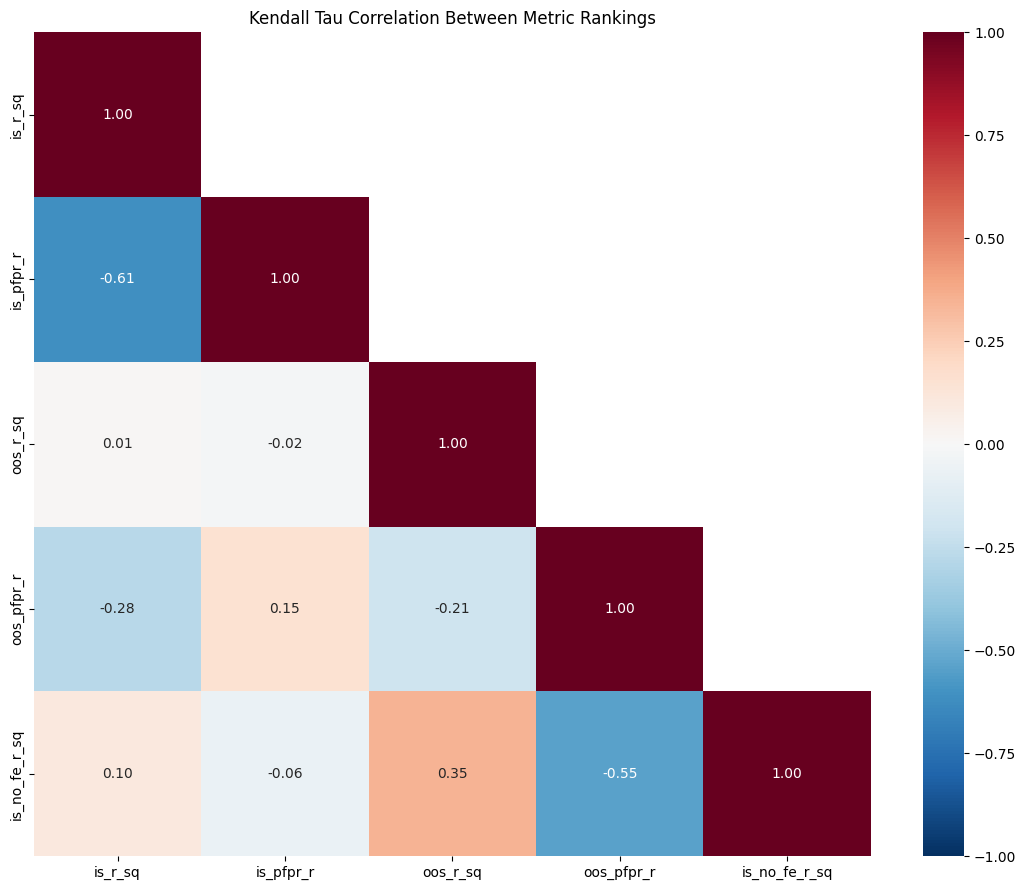


=== Metric Agreement Analysis ===
Average pairwise Kendall tau: -0.112
Pairs with negative correlation: 6
Low agreement. Flat top tier may be aggregation artifact (metric cancellation).


In [41]:
print(f'Kendall τ on {len(metric_df):,} tasks × {len(metrics_present)} metrics')
tau_df = kendall_tau_heatmap(metric_df, metrics_present, calib_present, figsize=(11, 9))
plt.show()

## Borda count

Sum-of-ranks across metrics, with an auto-detected elbow / cutpoint for
where the top tier ends.

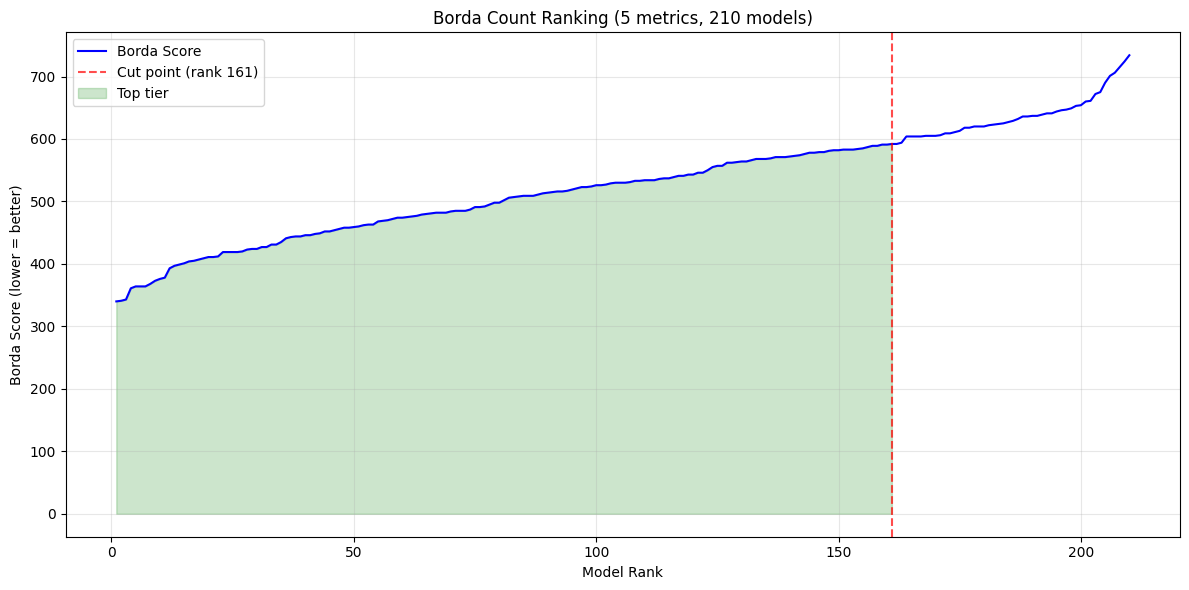


=== Borda Count Summary ===
Total models: 210
Metrics used: 5
Suggested cutpoint: rank 161 (top 161 models)
Top tier Borda range: 340.0 - 592.0
Bottom tier starts at: 592.0


,task_id,is_aic,is_bic,is_deviance,is_dev_expl,is_r_sq,is_rmse,is_mae,oos_rmse,oos_mae,oos_r_sq,is_pfpr_rmse,is_pfpr_mae,is_pfpr_r,oos_pfpr_rmse,oos_pfpr_mae,oos_pfpr_r,is_no_fe_aic,is_no_fe_bic,is_no_fe_dev_expl,is_no_fe_r_sq,is_no_fe_rmse,is_no_fe_mae,borda_score,borda_rank
0,23,1.411521e+06,1.412326e+06,2.314285e+06,0.819459,0.819459,2.842417,1.985761,5.406422,4.461060,0.346840,0.081869,0.034602,0.872796,0.180094,0.084297,0.153367,1.716425e+06,1.716514e+06,0.476323,0.476323,4.840965,3.937655,340.0,1.0
1,32,1.399932e+06,1.400731e+06,2.222539e+06,0.826616,0.826616,2.785506,1.962391,5.503637,4.524261,0.323139,0.090081,0.037409,0.848235,0.182140,0.086011,0.118482,1.715916e+06,1.715991e+06,0.477248,0.477248,4.836685,3.919107,341.0,2.0
2,30,1.400284e+06,1.401084e+06,2.225273e+06,0.826403,0.826403,2.787218,1.963646,5.546436,4.567179,0.312571,0.089615,0.037208,0.850046,0.180643,0.085062,0.132881,1.716568e+06,1.716643e+06,0.476056,0.476056,4.842196,3.934458,343.0,3.0
3,2,1.412234e+06,1.413019e+06,2.320093e+06,0.819006,0.819006,2.845982,1.984020,5.399969,4.451391,0.348398,0.080420,0.033871,0.877103,0.179908,0.084052,0.161549,1.717726e+06,1.717790e+06,0.473932,0.473932,4.852004,3.947641,361.0,4.0
4,58,1.403590e+06,1.404436e+06,2.251032e+06,0.824394,0.824394,2.803304,1.985578,5.399968,4.451391,0.348398,0.096332,0.039830,0.831426,0.179908,0.084052,0.161550,1.717726e+06,1.717790e+06,0.473931,0.473931,4.852004,3.947641,364.0,6.0
5,39,1.395561e+06,1.396389e+06,2.188838e+06,0.829245,0.829245,2.764306,1.967686,5.458780,4.490942,0.334127,0.098622,0.040984,0.825840,0.183162,0.086780,0.105301,1.715917e+06,1.715999e+06,0.477248,0.477248,4.836683,3.919128,364.0,6.0
6,170,1.394239e+06,1.395070e+06,2.178750e+06,0.830032,0.830032,2.757929,1.971066,5.546436,4.567179,0.312571,0.104093,0.042832,0.808263,0.180643,0.085062,0.132881,1.716568e+06,1.716643e+06,0.476056,0.476056,4.842196,3.934457,364.0,6.0
7,172,1.393896e+06,1.394728e+06,2.176145e+06,0.830236,0.830236,2.756279,1.969916,5.503672,4.524292,0.323130,0.104407,0.043027,0.806823,0.182141,0.086012,0.118466,1.715916e+06,1.715991e+06,0.477248,0.477248,4.836684,3.919106,368.0,8.0
8,9,1.412226e+06,1.413021e+06,2.320007e+06,0.819013,0.819013,2.845929,1.984643,5.422741,4.474250,0.342891,0.080516,0.033922,0.876788,0.180138,0.084315,0.152739,1.717727e+06,1.717802e+06,0.473932,0.473932,4.852000,3.947739,373.0,9.0
9,25,1.411694e+06,1.412505e+06,2.315684e+06,0.819350,0.819350,2.843276,1.986655,5.381001,4.433074,0.352967,0.082333,0.034788,0.870540,0.181915,0.085149,0.126942,1.716065e+06,1.716153e+06,0.476981,0.476981,4.837921,3.925909,376.0,10.0


In [42]:
borda_df, borda_cutpoint = borda_rank(metric_df, metrics_present, calib_present)
borda_df.head(10)

## TOPSIS

Distance-to-ideal scoring with min-max normalisation (equal influence per
metric). `influence` reports per-metric separation power.

In [43]:
topsis_df, influence = topsis_rank(metric_df, metrics_present, calib_present, verbose=True)
topsis_df.head(10)


=== TOPSIS Ranking (normalize=minmax) ===
Models ranked: 210
Metrics used: 5

Top 10 by TOPSIS:
   topsis_rank  topsis_score   is_r_sq  is_pfpr_r  oos_r_sq  oos_pfpr_r  is_no_fe_r_sq
0          1.0      0.590098  0.826616   0.848235  0.323139    0.118482       0.477248
1          2.0      0.587205  0.826403   0.850046  0.312571    0.132881       0.476056
2          3.0      0.586539  0.824394   0.831426  0.348398    0.161550       0.473931
3          4.0      0.583565  0.819006   0.877103  0.348398    0.161549       0.473932
4          5.0      0.583463  0.819459   0.872796  0.346840    0.153367       0.476323
5          6.0      0.582261  0.828986   0.805556  0.348398    0.161550       0.473931
6          7.0      0.574684  0.829245   0.825840  0.334127    0.105301       0.477248
7          8.0      0.572350  0.819013   0.876788  0.342891    0.152739       0.473932
8          9.0      0.570863  0.828999   0.806111  0.342891    0.152740       0.473932
9         10.0      0.568436  0.8

,task_id,is_aic,is_bic,is_deviance,is_dev_expl,is_r_sq,is_rmse,is_mae,oos_rmse,oos_mae,oos_r_sq,is_pfpr_rmse,is_pfpr_mae,is_pfpr_r,oos_pfpr_rmse,oos_pfpr_mae,oos_pfpr_r,is_no_fe_aic,is_no_fe_bic,is_no_fe_dev_expl,is_no_fe_r_sq,is_no_fe_rmse,is_no_fe_mae,topsis_score,topsis_rank
0,32,1.399932e+06,1.400731e+06,2.222539e+06,0.826616,0.826616,2.785506,1.962391,5.503637,4.524261,0.323139,0.090081,0.037409,0.848235,0.182140,0.086011,0.118482,1.715916e+06,1.715991e+06,0.477248,0.477248,4.836685,3.919107,0.590098,1.0
1,30,1.400284e+06,1.401084e+06,2.225273e+06,0.826403,0.826403,2.787218,1.963646,5.546436,4.567179,0.312571,0.089615,0.037208,0.850046,0.180643,0.085062,0.132881,1.716568e+06,1.716643e+06,0.476056,0.476056,4.842196,3.934458,0.587205,2.0
2,58,1.403590e+06,1.404436e+06,2.251032e+06,0.824394,0.824394,2.803304,1.985578,5.399968,4.451391,0.348398,0.096332,0.039830,0.831426,0.179908,0.084052,0.161550,1.717726e+06,1.717790e+06,0.473931,0.473931,4.852004,3.947641,0.586539,3.0
3,2,1.412234e+06,1.413019e+06,2.320093e+06,0.819006,0.819006,2.845982,1.984020,5.399969,4.451391,0.348398,0.080420,0.033871,0.877103,0.179908,0.084052,0.161549,1.717726e+06,1.717790e+06,0.473932,0.473932,4.852004,3.947641,0.583565,4.0
4,23,1.411521e+06,1.412326e+06,2.314285e+06,0.819459,0.819459,2.842417,1.985761,5.406422,4.461060,0.346840,0.081869,0.034602,0.872796,0.180094,0.084297,0.153367,1.716425e+06,1.716514e+06,0.476323,0.476323,4.840965,3.937655,0.583463,5.0
5,142,1.395998e+06,1.396834e+06,2.192163e+06,0.828986,0.828986,2.766405,1.978163,5.399968,4.451392,0.348398,0.105409,0.043219,0.805556,0.179908,0.084052,0.161550,1.717726e+06,1.717790e+06,0.473931,0.473931,4.852007,3.947644,0.582261,6.0
6,39,1.395561e+06,1.396389e+06,2.188838e+06,0.829245,0.829245,2.764306,1.967686,5.458780,4.490942,0.334127,0.098622,0.040984,0.825840,0.183162,0.086780,0.105301,1.715917e+06,1.715999e+06,0.477248,0.477248,4.836683,3.919128,0.574684,7.0
7,9,1.412226e+06,1.413021e+06,2.320007e+06,0.819013,0.819013,2.845929,1.984643,5.422741,4.474250,0.342891,0.080516,0.033922,0.876788,0.180138,0.084315,0.152739,1.717727e+06,1.717802e+06,0.473932,0.473932,4.852000,3.947739,0.572350,8.0
8,149,1.395977e+06,1.396822e+06,2.191991e+06,0.828999,0.828999,2.766296,1.977469,5.422741,4.474251,0.342891,0.105281,0.043157,0.806111,0.180138,0.084315,0.152740,1.717728e+06,1.717803e+06,0.473932,0.473932,4.852004,3.947743,0.570863,9.0
9,16,1.412203e+06,1.413011e+06,2.319800e+06,0.819029,0.819029,2.845802,1.985181,5.419573,4.475145,0.343658,0.080629,0.033980,0.876433,0.180308,0.084516,0.146462,1.717726e+06,1.717790e+06,0.473932,0.473932,4.852004,3.947641,0.568436,10.0


## Pareto frontier

Non-dominated set: tasks that no other task strictly beats on every
metric. Large frontiers mean genuine trade-offs across metrics; small
frontiers mean a few tasks dominate the field.

In [44]:
pareto_df = pareto_frontier(metric_df, metrics_present, calib_present)
print(f'\nFrontier size: {len(pareto_df):,} / {len(metric_df):,} '
      f'({100 * len(pareto_df) / len(metric_df):.1f}%)')
pareto_df.head(10)


=== Pareto Frontier ===
Total models: 210
Non-dominated: 150 (71.4%)
Dominated: 60

Frontier size: 150 / 210 (71.4%)


,task_id,is_aic,is_bic,is_deviance,is_dev_expl,is_r_sq,is_rmse,is_mae,oos_rmse,oos_mae,oos_r_sq,is_pfpr_rmse,is_pfpr_mae,is_pfpr_r,oos_pfpr_rmse,oos_pfpr_mae,oos_pfpr_r,is_no_fe_aic,is_no_fe_bic,is_no_fe_dev_expl,is_no_fe_r_sq,is_no_fe_rmse,is_no_fe_mae
0,1,1.412473e+06,1.413252e+06,2.322035e+06,0.818854,0.818854,2.847173,1.985712,5.615491,4.590519,0.295347,0.080750,0.034013,0.875502,0.178830,0.082469,0.255125,1.735822e+06,1.735864e+06,0.439616,0.439616,5.007753,4.052990
1,2,1.412234e+06,1.413019e+06,2.320093e+06,0.819006,0.819006,2.845982,1.984020,5.399969,4.451391,0.348398,0.080420,0.033871,0.877103,0.179908,0.084052,0.161549,1.717726e+06,1.717790e+06,0.473932,0.473932,4.852004,3.947641
2,3,1.412221e+06,1.412995e+06,2.320001e+06,0.819013,0.819013,2.845925,1.983988,5.615517,4.590538,0.295340,0.080431,0.033877,0.877081,0.178830,0.082469,0.255106,1.735822e+06,1.735865e+06,0.439616,0.439616,5.007753,4.052990
3,4,1.412389e+06,1.413179e+06,2.321342e+06,0.818909,0.818909,2.846747,1.985197,5.375138,4.420396,0.354377,0.080999,0.034095,0.874620,0.181886,0.085145,0.127455,1.717695e+06,1.717759e+06,0.473988,0.473988,4.851741,3.935915
4,5,1.412474e+06,1.413252e+06,2.322040e+06,0.818854,0.818854,2.847175,1.985715,5.615491,4.590519,0.295347,0.080749,0.034013,0.875504,0.178830,0.082469,0.255125,1.735822e+06,1.735864e+06,0.439616,0.439616,5.007753,4.052989
5,6,1.412098e+06,1.412887e+06,2.318978e+06,0.819093,0.819093,2.845297,1.983543,5.493337,4.549711,0.325670,0.081099,0.034119,0.874329,0.180733,0.085181,0.130577,1.721853e+06,1.721918e+06,0.466296,0.466296,4.887087,3.987664
6,7,1.412473e+06,1.413251e+06,2.322033e+06,0.818855,0.818855,2.847171,1.985710,5.640542,4.612927,0.289046,0.080750,0.034013,0.875503,0.178830,0.082471,0.255084,1.735822e+06,1.735864e+06,0.439616,0.439616,5.007753,4.052990
8,9,1.412226e+06,1.413021e+06,2.320007e+06,0.819013,0.819013,2.845929,1.984643,5.422741,4.474250,0.342891,0.080516,0.033922,0.876788,0.180138,0.084315,0.152739,1.717727e+06,1.717802e+06,0.473932,0.473932,4.852000,3.947739
9,10,1.412212e+06,1.412996e+06,2.319909e+06,0.819020,0.819020,2.845869,1.984596,5.645263,4.622946,0.287855,0.080529,0.033929,0.876761,0.179722,0.083108,0.191787,1.735650e+06,1.735702e+06,0.439957,0.439957,5.006227,4.054246
10,11,1.412384e+06,1.413184e+06,2.321283e+06,0.818913,0.818913,2.846711,1.985698,5.400909,4.448171,0.348171,0.081069,0.034135,0.874388,0.182330,0.085397,0.121942,1.717666e+06,1.717741e+06,0.474045,0.474045,4.851481,3.936895


## Pairwise dominance

For each pair (A, B), A beats B if A wins on a majority of metrics.
`dominance_count` = how many tasks each task beats.

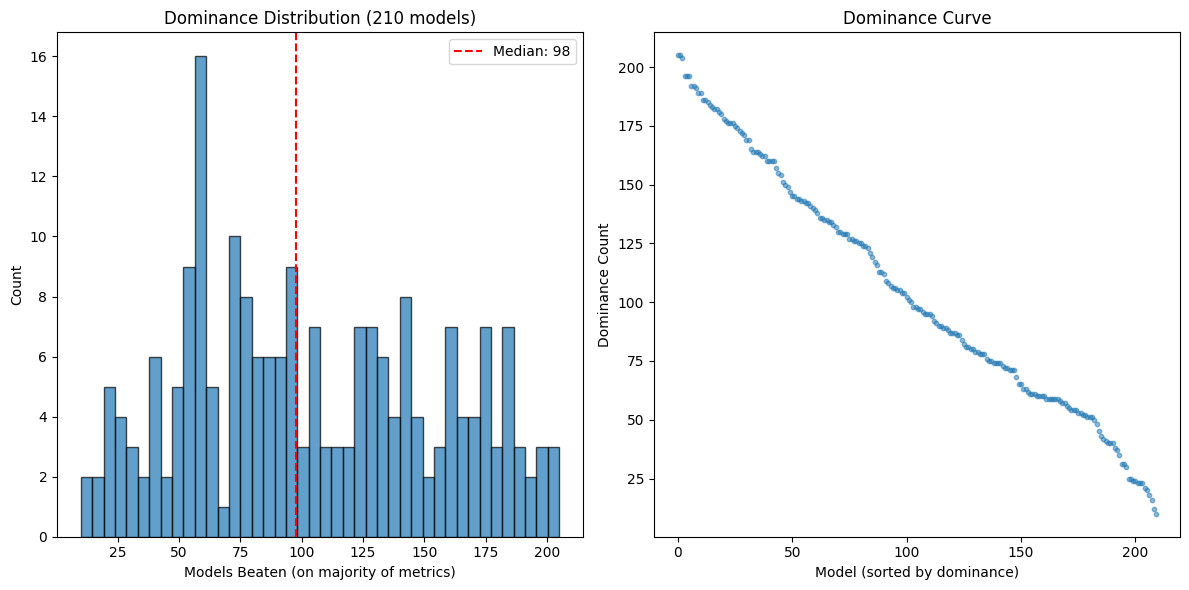


=== Pairwise Dominance Summary ===
Models compared: 210
Metrics used: 5
Max dominance: 205 / 209 models beaten
Median dominance: 98

Top 10 most dominant models:
   dominance_rank  dominance_count  dominance_pct  task_id
0             1.5              205      98.086124        2
1             1.5              205      98.086124       23
2             3.0              204      97.607656       25
3             5.0              196      93.779904       39
4             5.0              196      93.779904       58
5             5.0              196      93.779904        9
6             7.5              192      91.866029       16
7             7.5              192      91.866029      172
8             9.0              191      91.387560       32
9            10.5              189      90.430622        4


,task_id,is_aic,is_bic,is_deviance,is_dev_expl,is_r_sq,is_rmse,is_mae,oos_rmse,oos_mae,oos_r_sq,is_pfpr_rmse,is_pfpr_mae,is_pfpr_r,oos_pfpr_rmse,oos_pfpr_mae,oos_pfpr_r,is_no_fe_aic,is_no_fe_bic,is_no_fe_dev_expl,is_no_fe_r_sq,is_no_fe_rmse,is_no_fe_mae,dominance_count,dominance_pct,total_metric_wins,dominance_rank
0,2,1.412234e+06,1.413019e+06,2.320093e+06,0.819006,0.819006,2.845982,1.984020,5.399969,4.451391,0.348398,0.080420,0.033871,0.877103,0.179908,0.084052,0.161549,1.717726e+06,1.717790e+06,0.473932,0.473932,4.852004,3.947641,205,98.086124,689,1.5
1,23,1.411521e+06,1.412326e+06,2.314285e+06,0.819459,0.819459,2.842417,1.985761,5.406422,4.461060,0.346840,0.081869,0.034602,0.872796,0.180094,0.084297,0.153367,1.716425e+06,1.716514e+06,0.476323,0.476323,4.840965,3.937655,205,98.086124,710,1.5
2,25,1.411694e+06,1.412505e+06,2.315684e+06,0.819350,0.819350,2.843276,1.986655,5.381001,4.433074,0.352967,0.082333,0.034788,0.870540,0.181915,0.085149,0.126942,1.716065e+06,1.716153e+06,0.476981,0.476981,4.837921,3.925909,204,97.607656,674,3.0
3,39,1.395561e+06,1.396389e+06,2.188838e+06,0.829245,0.829245,2.764306,1.967686,5.458780,4.490942,0.334127,0.098622,0.040984,0.825840,0.183162,0.086780,0.105301,1.715917e+06,1.715999e+06,0.477248,0.477248,4.836683,3.919128,196,93.779904,686,5.0
4,58,1.403590e+06,1.404436e+06,2.251032e+06,0.824394,0.824394,2.803304,1.985578,5.399968,4.451391,0.348398,0.096332,0.039830,0.831426,0.179908,0.084052,0.161550,1.717726e+06,1.717790e+06,0.473931,0.473931,4.852004,3.947641,196,93.779904,686,5.0
5,9,1.412226e+06,1.413021e+06,2.320007e+06,0.819013,0.819013,2.845929,1.984643,5.422741,4.474250,0.342891,0.080516,0.033922,0.876788,0.180138,0.084315,0.152739,1.717727e+06,1.717802e+06,0.473932,0.473932,4.852000,3.947739,196,93.779904,677,5.0
6,16,1.412203e+06,1.413011e+06,2.319800e+06,0.819029,0.819029,2.845802,1.985181,5.419573,4.475145,0.343658,0.080629,0.033980,0.876433,0.180308,0.084516,0.146462,1.717726e+06,1.717790e+06,0.473932,0.473932,4.852004,3.947641,192,91.866029,672,7.5
7,172,1.393896e+06,1.394728e+06,2.176145e+06,0.830236,0.830236,2.756279,1.969916,5.503672,4.524292,0.323130,0.104407,0.043027,0.806823,0.182141,0.086012,0.118466,1.715916e+06,1.715991e+06,0.477248,0.477248,4.836684,3.919106,192,91.866029,682,7.5
8,32,1.399932e+06,1.400731e+06,2.222539e+06,0.826616,0.826616,2.785506,1.962391,5.503637,4.524261,0.323139,0.090081,0.037409,0.848235,0.182140,0.086011,0.118482,1.715916e+06,1.715991e+06,0.477248,0.477248,4.836685,3.919107,191,91.387560,709,9.0
9,4,1.412389e+06,1.413179e+06,2.321342e+06,0.818909,0.818909,2.846747,1.985197,5.375138,4.420396,0.354377,0.080999,0.034095,0.874620,0.181886,0.085145,0.127455,1.717695e+06,1.717759e+06,0.473988,0.473988,4.851741,3.935915,189,90.430622,641,10.5


In [45]:
dominance_df = pairwise_dominance_summary(metric_df, metrics_present, calib_present)
dominance_df.head(10)

## Winners by method

Side-by-side comparison of the top pick from each method on a shared
metric set. Pareto frontier has no canonical order — `pareto_first` is
the first row of the frontier (df order), not a "best" frontier member.

In [50]:
winners = {
    'borda':              borda_df.iloc[0],
    'topsis':             topsis_df.iloc[0],
    'pareto_first':       pareto_df.iloc[0],
    'pairwise_dominance': dominance_df.iloc[0],
}

show_cols = [c for c in CONFIG_COLS if c in metric_df.columns] + [
    'is_aic', 'is_bic', 'is_dev_expl', 'is_r_sq',
    'oos_rmse', 'oos_mae', 'oos_r_sq',
    'is_pfpr_r', 'oos_pfpr_r',
]
show_cols = [c for c in show_cols if c in metric_df.columns]
metrics_present
winners_df = pd.DataFrame({k: w[show_cols] for k, w in winners.items()}).T
winners_df

,task_id,is_aic,is_bic,is_dev_expl,is_r_sq,oos_rmse,oos_mae,oos_r_sq,is_pfpr_r,oos_pfpr_r
borda,23.0,1.411521e+06,1.412326e+06,0.819459,0.819459,5.406422,4.461060,0.346840,0.872796,0.153367
topsis,32.0,1.399932e+06,1.400731e+06,0.826616,0.826616,5.503637,4.524261,0.323139,0.848235,0.118482
pareto_first,1.0,1.412473e+06,1.413252e+06,0.818854,0.818854,5.615491,4.590519,0.295347,0.875502,0.255125
pairwise_dominance,2.0,1.412234e+06,1.413019e+06,0.819006,0.819006,5.399969,4.451391,0.348398,0.877103,0.161549


The history saving thread hit an unexpected error (OperationalError('unable to open database file')).History will not be written to the database.

In [51]:
metrics_present

{'is_r_sq': 'higher',
 'is_pfpr_r': 'higher',
 'oos_r_sq': 'higher',
 'oos_pfpr_r': 'higher',
 'is_no_fe_r_sq': 'higher'}